# Groupe D - Projet 1 
**Membres du Groupe :**

*   ABEGUEDIA Rosane Yvanne Boyama
*   BARRY Mamoudou
*   DAMIENS Elodie
*   GUILLEMINOT Paul
*   TOUAMI Zakaria

# Prédiction du succès d'une campagne marketing bancaire

Les banques utilisent régulièrement des campagnes téléphoniques pour proposer des produits financiers à leurs clients. Cependant, ces campagnes peuvent être coûteuses et inefficaces si les clients ciblés ne sont pas susceptibles d’accepter l’offre.

L’objectif de ce projet est d’analyser les données d’une campagne marketing bancaire afin de :

- comprendre quels profils de clients répondent positivement ;
- identifier les facteurs influençant la souscription à un produit d’épargne ;
- construire un modèle permettant de prédire quels clients sont les plus susceptibles d’accepter l’offre.

Nous utiliserons le **Bank Marketing Dataset**, qui contient des informations sur des clients contactés lors de campagnes téléphoniques.

Le projet se déroule en plusieurs étapes :

1. Compréhension et exploration des données (EDA)
2. Analyse des relations entre les variables et la souscription
3. Création de nouvelles variables pertinentes
4. Construction d’un modèle de classification
5. Évaluation et interprétation des résultats

Import des librairies :

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Chargement des données :

In [41]:
data = pd.read_csv("bank-full.csv", sep=";")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1. Compréhension et exploration des données (EDA)

Chaque ligne correspond à un client contacté lors d'une campagne marketing.

La variable cible du dataset est **y**, qui indique si le client a souscrit au produit d’épargne proposé.

Valeurs possibles :
- yes : le client a souscrit
- no : le client n’a pas souscrit

In [42]:
data.shape

(45211, 17)

Le dataset contient **45 211 observations** et **17 variables**.

In [43]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

**Description des variables**

| Variable | Description |
|------|------|
| age | âge du client |
| job | profession du client |
| marital | statut marital |
| education | niveau d’éducation |
| default | crédit en défaut |
| balance | solde bancaire |
| housing | prêt immobilier |
| loan | prêt personnel |
| contact | type de contact |
| day | jour du contact |
| month | mois du contact |
| duration | durée de l’appel |
| campaign | nombre de contacts pendant la campagne |
| pdays | jours depuis le dernier contact |
| previous | nombre de contacts précédents |
| poutcome | résultat de la campagne précédente |
| y | variable cible (souscription au produit) |

Vérification des données manquantes

In [44]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Aucune valeur manquante n’est observée dans le dataset. Les données sont donc complètes et directement exploitables.

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Le dataset contient :

- des variables numériques (âge, solde bancaire, durée d'appel…)
- des variables catégorielles (profession, statut marital, type de contact…)

## Analyse univariée
# Distribution de l'âge

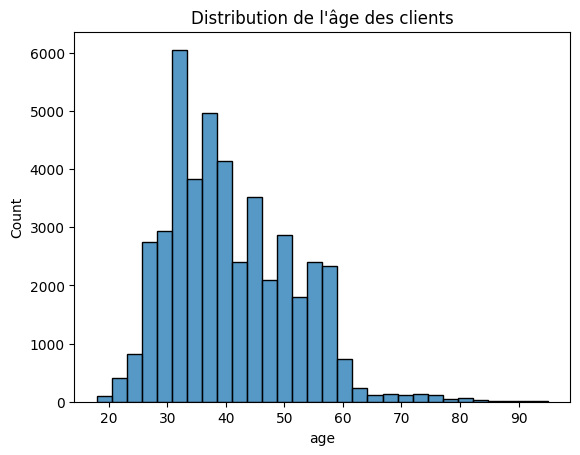

In [46]:
sns.histplot(data["age"], bins=30)
plt.title("Distribution de l'âge des clients")
plt.show()